In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

import operator
import os

load_dotenv()

True

In [5]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
GROQ_MODEL=os.getenv("GROQ_MODEL")

In [6]:
model = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [7]:
class QuadState(TypedDict):
    a: str
    b: str
    c: str
    
    eduation: str
    discriminent: float
    result: str

In [8]:
def show_equation(state: QuadState):
    eduation = f"{state['a']}x² + {state['b']}x + {state['c']}"
    return {
        'eduation': eduation
    }

In [9]:
def calculate_discriminent(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    
    discriminent = b**2 - (4 * a * c)
    
    return {'discriminent': discriminent}


In [10]:
def real_roots(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminent = state['discriminent']
    
    root1 = (-b + discriminent**0.5) / (2 * a)
    root2 = (-b - discriminent**0.5) / (2 * a)
    
    result = f"The roots are: {root1} and {root2}"
    return {"result": result}


def repeated_roots(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    
    root = -b / (2 * a)
    
    result = f"The only repeating root is: {root}"
    return {"result": result}


def non_real_roots(state: QuadState):
    result = f"No real roots"
    return {"result": result}


def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "non_real_roots"]:
    discriminent = state["discriminent"]
    
    if discriminent > 0:
        return "real_roots"
    elif discriminent == 0:
        return "repeated_roots"
    else:
        return "non_real_roots"

In [11]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminent', calculate_discriminent)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('non_real_roots', non_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminent')

graph.add_conditional_edges('calculate_discriminent', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('non_real_roots', END)

workflow = graph.compile()

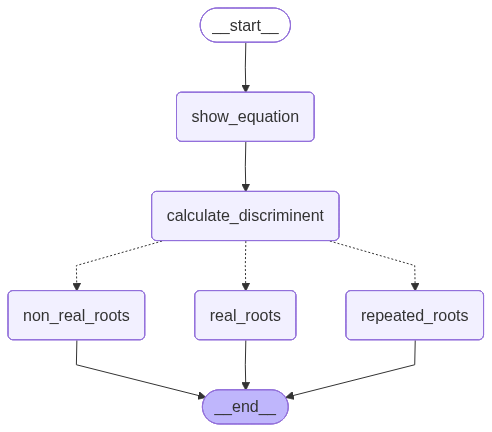

In [12]:
workflow

In [13]:
initial_state = {
    'a': 4,
    'b': 2,
    'c': 4
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 4, 'b': 2, 'c': 4, 'eduation': '4x² + 2x + 4', 'discriminent': -60, 'result': 'No real roots'}
